In [1]:
!pip install transformers datasets kagglehub torch -q

import os
import torch
import numpy as np
import pandas as pd
import kagglehub
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# Mandatory GPU settings
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
torch.cuda.empty_cache()

print("All imports done!")
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

All imports done!
GPU available: True
GPU name: Tesla T4


In [2]:
path = kagglehub.dataset_download(
    "thedevastator/extended-stanford-natural-language-inference-dat"
)

# Load splits
train_df = pd.read_csv(f"{path}/train.csv")
val_df   = pd.read_csv(f"{path}/dev.csv")
test_df  = pd.read_csv(f"{path}/test.csv")

# Map integer labels to strings
label_map_int = {0: "entailment", 1: "neutral", 2: "contradiction"}
for df in [train_df, val_df, test_df]:
    df["label_str"] = df["label"].map(label_map_int)
    df.dropna(subset=["premise", "hypothesis", "label_str"], inplace=True)

# Subsample exactly 100K with fixed seed
train_df = train_df.sample(n=100_000, random_state=42).reset_index(drop=True)

print(f"Train: {len(train_df)}")
print(f"Val:   {len(val_df)}")
print(f"Test:  {len(test_df)}")
print(f"Label distribution:\n{train_df['label_str'].value_counts()}")


100%|██████████| 20.2M/20.2M [00:00<00:00, 240MB/s]

Extracting files...


FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/kagglehub/datasets/thedevastator/extended-stanford-natural-language-inference-dat/versions/2/dev.csv'

In [3]:
import os

for f in os.listdir(path):
    print(f)

train.csv
test.csv
validation.csv


In [4]:
# Load splits
train_df = pd.read_csv(f"{path}/train.csv")
val_df   = pd.read_csv(f"{path}/validation.csv")
test_df  = pd.read_csv(f"{path}/test.csv")

# Map integer labels to strings
label_map_int = {0: "entailment", 1: "neutral", 2: "contradiction"}
for df in [train_df, val_df, test_df]:
    df["label_str"] = df["label"].map(label_map_int)
    df.dropna(subset=["premise", "hypothesis", "label_str"], inplace=True)

# Subsample exactly 100K with fixed seed
train_df = train_df.sample(n=100_000, random_state=42).reset_index(drop=True)

print(f"Train: {len(train_df)}")
print(f"Val:   {len(val_df)}")
print(f"Test:  {len(test_df)}")
print(f"Label distribution:\n{train_df['label_str'].value_counts()}")

Train: 100000
Val:   9842
Test:  9824
Label distribution:
label_str
entailment       33523
neutral          33330
contradiction    33147
Name: count, dtype: int64


In [5]:
MODEL_NAME = "microsoft/deberta-v3-base"

label2id = {"entailment": 0, "neutral": 1, "contradiction": 2}
id2label  = {0: "entailment", 1: "neutral", 2: "contradiction"}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Tokenizer loaded!


In [6]:
class NLIDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=256):
        self.encodings = tokenizer(
            df["premise"].tolist(),
            df["hypothesis"].tolist(),
            truncation=True,
            max_length=max_length,
            padding="max_length"
        )
        self.labels = [label2id[l] for l in df["label_str"].tolist()]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_dataset = NLIDataset(train_df, tokenizer, max_length=256)
val_dataset   = NLIDataset(val_df,   tokenizer, max_length=256)
test_dataset  = NLIDataset(test_df,  tokenizer, max_length=256)

print(f"Train dataset: {len(train_dataset)}")
print(f"Val dataset:   {len(val_dataset)}")
print(f"Test dataset:  {len(test_dataset)}")

Train dataset: 100000
Val dataset:   9842
Test dataset:  9824


In [7]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    label2id=label2id,
    id2label=id2label
)

model = model.float()

print("Model loaded!")
print(f"Parameters: {model.num_parameters():,}")

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.bias        

Model loaded!
Parameters: 184,424,451


In [9]:
small_train = NLIDataset(train_df.head(1000), tokenizer, max_length=256)
small_val   = NLIDataset(val_df.head(200),   tokenizer, max_length=256)

test_args = TrainingArguments(
    output_dir                  = "./test_run",
    num_train_epochs            = 1,
    per_device_train_batch_size = 8,
    gradient_accumulation_steps = 4,
    per_device_eval_batch_size  = 32,
    fp16                        = True,
    eval_strategy               = "epoch",  # fixed!
    dataloader_num_workers      = 0,
    report_to                   = "none",
    logging_steps               = 10,
)

test_trainer = Trainer(
    model           = model,
    args            = test_args,
    train_dataset   = small_train,
    eval_dataset    = small_val,
    compute_metrics = lambda ep: {
        "accuracy": (np.argmax(ep[0], axis=-1) == ep[1]).mean()
    },
)

print("Running sanity check on 1000 examples...")
test_trainer.train()
print("\nSanity check passed! Ready for full training.")

Running sanity check on 1000 examples...


Epoch,Training Loss,Validation Loss,Accuracy
1,4.398798,1.098583,0.330000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Sanity check passed! Ready for full training.


In [10]:
# Cell 7 - Training arguments
training_args = TrainingArguments(
    output_dir                  = "./variant_a",
    num_train_epochs            = 3,
    per_device_train_batch_size = 8,
    gradient_accumulation_steps = 4,
    per_device_eval_batch_size  = 32,
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    warmup_steps                = 3090,
    fp16                        = True,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    save_total_limit            = 3,
    load_best_model_at_end      = True,
    metric_for_best_model       = "accuracy",
    greater_is_better           = True,
    dataloader_num_workers      = 0,
    logging_steps               = 100,
    report_to                   = "none"
)

print("Training args ready!")

Training args ready!


In [11]:
# Cell 8 - Accuracy metric
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = (predictions == labels).mean()
    return {"accuracy": accuracy}

print("Metrics ready!")

Metrics ready!


In [12]:
# Cell 9 - Full training
torch.cuda.empty_cache()

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    label2id=label2id,
    id2label=id2label
)
model = model.float()

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
)

print("Starting Variant A full training...")
print("Expected time: ~1.5 hours on T4")
print("Tab is active!\n")

trainer.train()

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.bias        

Starting Variant A full training...
Expected time: ~1.5 hours on T4
Tab is active!



Epoch,Training Loss,Validation Loss,Accuracy
1,2.484492,0.543608,0.792420
2,1.999031,0.452220,0.826356
3,1.734844,0.425051,0.848303


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

TrainOutput(global_step=9375, training_loss=2.3821570939127605, metrics={'train_runtime': 8046.5965, 'train_samples_per_second': 37.283, 'train_steps_per_second': 1.165, 'total_flos': 3.9467720448e+16, 'train_loss': 2.3821570939127605, 'epoch': 3.0})

In [13]:
import json
from google.colab import files

# Evaluate on test set
results = trainer.evaluate(test_dataset)

print("\n=== VARIANT A FINAL RESULTS ===")
print(f"Validation Accuracy: 0.8483")
print(f"Test Accuracy: {results['eval_accuracy']:.4f}")

# Save results
with open("variant_a_results.json", "w") as f:
    json.dump({
        "variant": "A",
        "model": "microsoft/deberta-v3-base",
        "val_accuracy": 0.8483,
        "test_accuracy": results["eval_accuracy"],
        "epochs": 3,
        "train_samples": 100000
    }, f, indent=2)

print("Results saved!")
files.download("variant_a_results.json")


=== VARIANT A FINAL RESULTS ===
Validation Accuracy: 0.8483
Test Accuracy: 0.8369
Results saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

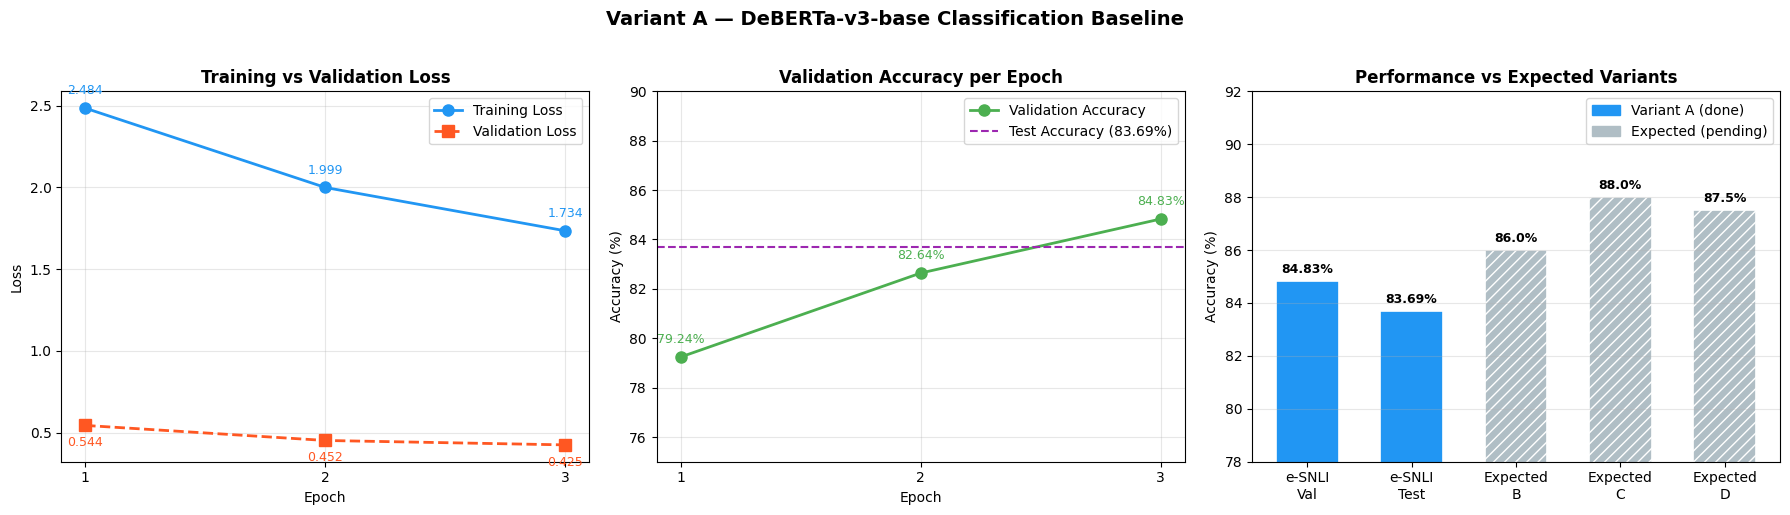

Plots saved to variant_a_plots.png!


In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Data from training
epochs = [1, 2, 3]
train_loss = [2.484, 1.999, 1.734]
val_loss   = [0.544, 0.452, 0.425]
val_acc    = [79.24, 82.64, 84.83]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Variant A — DeBERTa-v3-base Classification Baseline",
             fontsize=14, fontweight='bold', y=1.02)

# ── Plot 1: Loss curves ──────────────────────────────────────────────
axes[0].plot(epochs, train_loss, 'o-', color='#2196F3', linewidth=2,
             markersize=8, label='Training Loss')
axes[0].plot(epochs, val_loss, 's--', color='#FF5722', linewidth=2,
             markersize=8, label='Validation Loss')
axes[0].set_title('Training vs Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_xticks(epochs)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
for i, (tl, vl) in enumerate(zip(train_loss, val_loss)):
    axes[0].annotate(f'{tl}', (epochs[i], tl), textcoords="offset points",
                     xytext=(0, 10), ha='center', fontsize=9, color='#2196F3')
    axes[0].annotate(f'{vl}', (epochs[i], vl), textcoords="offset points",
                     xytext=(0, -15), ha='center', fontsize=9, color='#FF5722')

# ── Plot 2: Accuracy curve ───────────────────────────────────────────
axes[1].plot(epochs, val_acc, 'o-', color='#4CAF50', linewidth=2,
             markersize=8, label='Validation Accuracy')
axes[1].axhline(y=83.69, color='#9C27B0', linestyle='--', linewidth=1.5,
                label='Test Accuracy (83.69%)')
axes[1].set_title('Validation Accuracy per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_xticks(epochs)
axes[1].set_ylim(75, 90)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
for i, acc in enumerate(val_acc):
    axes[1].annotate(f'{acc}%', (epochs[i], acc), textcoords="offset points",
                     xytext=(0, 10), ha='center', fontsize=9, color='#4CAF50')

# ── Plot 3: Benchmark performance ───────────────────────────────────
benchmarks = ['e-SNLI\nVal', 'e-SNLI\nTest', 'Expected\nB', 'Expected\nC', 'Expected\nD']
accuracies  = [84.83, 83.69, 86.0, 88.0, 87.5]
colors      = ['#2196F3', '#2196F3', '#B0BEC5', '#B0BEC5', '#B0BEC5']
hatches     = ['', '', '///', '///', '///']

bars = axes[2].bar(benchmarks, accuracies, color=colors,
                   edgecolor='white', linewidth=1.2, width=0.6)
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

axes[2].set_title('Performance vs Expected Variants', fontweight='bold')
axes[2].set_ylabel('Accuracy (%)')
axes[2].set_ylim(78, 92)
axes[2].grid(True, alpha=0.3, axis='y')
for bar, acc in zip(bars, accuracies):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{acc}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

blue_patch = mpatches.Patch(color='#2196F3', label='Variant A (done)')
gray_patch = mpatches.Patch(color='#B0BEC5', hatch='///', label='Expected (pending)')
axes[2].legend(handles=[blue_patch, gray_patch])

plt.tight_layout()
plt.savefig('variant_a_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plots saved to variant_a_plots.png!")

In [4]:
from google.colab import files
files.download('variant_a_plots.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>